In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
path = "../datasets_raw/Analyzing_Europes_Biggest_Offshore_Wind_Farms/"
raw_filenames = ["Borssele_(Phase_1,2).csv", "Borssele_(Phase_3,4).csv","Gemini.csv","Hollandse_Kust_Noord.csv","Hollandse_Kust_Zuid.csv"]
wind_farm_names = ["Borssele_12","Borssele_34","Gemini", "Hollandse_Kust_Noord", "Hollandse_Kust_Zuid"]

for i, file in enumerate(raw_filenames):
    df = pd.read_csv(path + file)
    #drop unused columns
    df = df.drop(columns=["u100", "v100","fsr", "Unnamed: 0"])
    df = df.drop(columns=[col for col in df.columns if col.startswith("Power_of_")])
    # Rename Scaled Windspeed
    df.columns = [col if not col.startswith("Scaled_Windspeed") else "Scaled_Windspeed" for col in df.columns]
    df = df.set_index("time")
    df.index = pd.to_datetime(df.index)
    df["Station"] = wind_farm_names[i]
    df.to_csv("../datasets/offshore_"+ wind_farm_names[i] + ".csv", index=False)

In [8]:
print(df)

                     Windspeed  Scaled_Windspeed  Wind_Direction  Turn_off  \
time                                                                         
1980-01-01 00:00:00  13.401993         14.063049       138.26736         1   
1980-01-01 01:00:00  12.405228         13.017111       137.86499         1   
1980-01-01 02:00:00  11.671988         12.247699       138.37833         1   
1980-01-01 03:00:00  11.082034         11.628642       139.18219         1   
1980-01-01 04:00:00  10.737633         11.267252       141.37885         1   
...                        ...               ...             ...       ...   
2019-12-31 19:00:00   6.862277          7.200742       332.69740         1   
2019-12-31 20:00:00   7.444418          7.811595       331.21753         1   
2019-12-31 21:00:00   7.882492          8.271279       322.83173         1   
2019-12-31 22:00:00   7.990864          8.384996       310.78780         1   
2019-12-31 23:00:00   7.915882          8.306315       307.23980

In [4]:
#Check for duplicate timestamps
#Check for missing timestamps (gaps in the hourly sequence)
#Handle missing values (forward fill or interpolate for short gaps, flag long gaps)
#Check for physically impossible values (negative wind speed, power > capacity, wind speed > ~50 m/s)

In [9]:
# 1. Duplicate timestamps
dupes = df[df.index.duplicated()]
print(f"Duplicate timestamps: {len(dupes)}")
if len(dupes) > 0:
    print(dupes)

Duplicate timestamps: 0


In [10]:
# 2. Missing timestamps (gaps in hourly sequence)
expected_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h")
missing_timestamps = expected_range.difference(df.index)
print(f"\nMissing timestamps: {len(missing_timestamps)}")
if len(missing_timestamps) > 0:
    print(missing_timestamps)


Missing timestamps: 0


In [11]:
# 3. Missing values
print(f"\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
Windspeed           0
Scaled_Windspeed    0
Wind_Direction      0
Turn_off            0
Power               0
Station             0
dtype: int64


In [12]:
# Flag gaps longer than 3 hours before filling
gap_threshold = 3
for col in ["Windspeed", "Power"]:
    long_gaps = df[col].isna().astype(int).groupby(
        (df[col].notna()).cumsum()
    ).sum()
    long_gaps = long_gaps[long_gaps > gap_threshold]
    if len(long_gaps) > 0:
        print(f"\nLong gaps (>{gap_threshold}h) in {col}: {len(long_gaps)}")

# Forward fill short gaps, interpolate for slightly longer ones
#df["Windspeed"] = df["Windspeed"].ffill(limit=3)
#df["Power"] = df["Power"].interpolate(method="linear", limit=3)

In [21]:
# 4. Physically impossible values
capacity = 1540

print(f"\nNegative wind speed: {(df['Windspeed'] < 0).sum()}")
print(f"Wind speed > 50 m/s: {(df['Windspeed'] > 50).sum()}")
print(f"Negative power: {(df['Power'] < 0).sum()}")
print(f"Power > capacity ({capacity} MW): {(df['Power'] > capacity).sum()}")
print(f"Wind direction < 0: {(df['Wind_Direction'] < 0).sum()}")
print(f"Wind direction > 360: {(df['Wind_Direction'] > 360).sum()}")

# Flag them rather than drop
df["flag_suspicious"] = (
    (df["Windspeed"] < 0) |
    (df["Windspeed"] > 50) |
    (df["Power"] < 0) |
    (df["Power"] > capacity)
)
print(f"\nTotal flagged rows: {df['flag_suspicious'].sum()}")


Negative wind speed: 0
Wind speed > 50 m/s: 0
Negative power: 0
Power > capacity (1540 MW): 0
Wind direction < 0: 0
Wind direction > 360: 0

Total flagged rows: 0


In [ ]:
# 1. Flag Turn_off inconsistencies
# Turn_off == 0 but power is non-zero
flag_on_but_no_power = (df["Turn_off"] == 0) & (df["Power"] > 0)
# Turn_off == 1 but power is zero
flag_off_but_power = (df["Turn_off"] == 1) & (df["Power"] == 0)

print(f"Turn_off=0 but Power > 0: {flag_on_but_no_power.sum()}")
print(f"Turn_off=1 but Power = 0: {flag_off_but_power.sum()}")

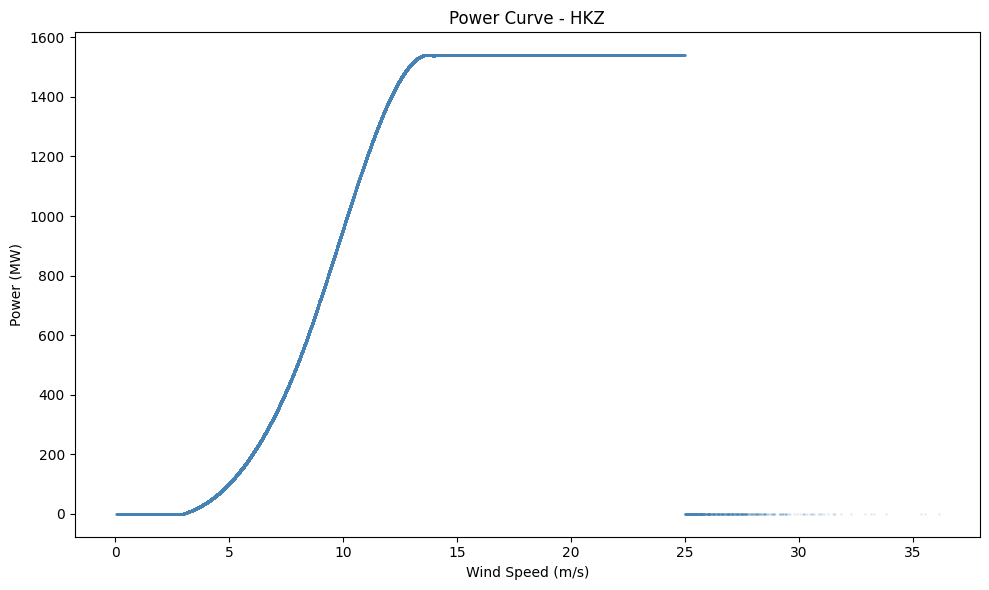

In [23]:
# 2. Power curve plot
fig, ax = plt.subplots(figsize=(10, 6))

# Normal points
ax.scatter(df["Scaled_Windspeed"],
           df["Power"],
           alpha=0.1, s=1, color="steelblue")

ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Power (MW)")
ax.set_title("Power Curve - HKZ")
plt.tight_layout()
plt.show()

In [24]:
# Find the minimum wind speed in the high-wind zero-power cluster
cut_out = high_wind_zero_power["Scaled_Windspeed"].min()
print(f"Estimated cut-out wind speed: {cut_out:.2f} m/s")

# Flag all hours above cut-out as cut-out events
df["flag_cutout"] = (df["Scaled_Windspeed"] >= cut_out) & (df["Power"] < 10)
print(f"Cut-out hours: {df['flag_cutout'].sum()}")

Estimated cut-out wind speed: 25.00 m/s
Cut-out hours: 636
